In [5]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt 

In [6]:
# load up vitb16 WHOI and UH results 
path_whoi = "/Users/birdy/Documents/mit-meng-thesis/results/vitb16_WHOI2014_results.csv"
path_uh = "/Users/birdy/Documents/mit-meng-thesis/results/vitb16_UH_results.csv" 
df_whoi = pd.read_csv(path_whoi)
df_uh = pd.read_csv(path_uh)

In [7]:
df_whoi

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history
0,vitb16,CrossEntropyLoss,adamw,CosineAnnealingLR,0.001,128,0.934155,0.345711,17566.910257,8586.436542,"{'train_loss': [0.5769160203782294, 0.40513322..."


In [8]:
df_uh

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history
0,vitb16,CrossEntropyLoss,adamw,CosineAnnealingLR,0.001,128,0.712664,0.230407,17566.956337,16530.495985,"{'train_loss': [1.7577876096373077, 1.28660006..."


In [13]:
import json
history = df_whoi.iloc[0]['history']
history = history.replace("\'", "\"")
# load json object
history = json.loads(history)

In [21]:
history.keys()

dict_keys(['train_loss', 'train_acc', 'train_class_acc', 'train_epoch_duration', 'val_epochs', 'val_loss', 'val_acc', 'val_class_acc', 'val_epoch_duration', 'time_elapsed'])

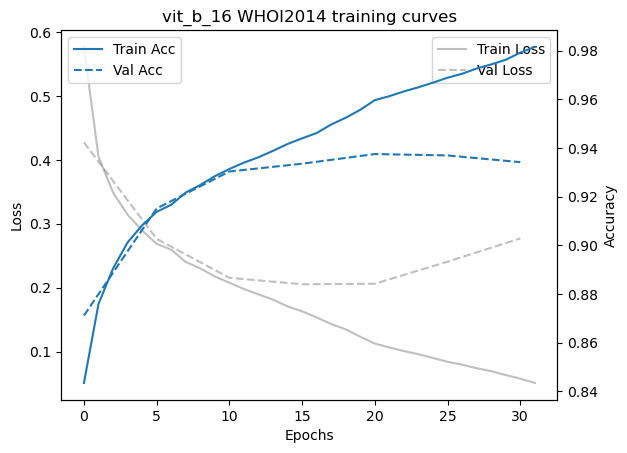

In [36]:
history = df_whoi.iloc[0]['history']
history = history.replace("\'", "\"")
# load json object
history = json.loads(history)

fig, ax = plt.subplots()
NUM_EPOCHS = len(history["train_loss"])
ax.plot(range(NUM_EPOCHS), history["train_loss"], label="Train Loss", color="grey", alpha=0.5)
ax.plot(history["val_epochs"], history["val_loss"], label="Val Loss", color="grey", alpha=0.5, ls="--")
ax2 = ax.twinx()
ax2.plot(range(NUM_EPOCHS), history["train_acc"], label="Train Acc", color="tab:blue")
ax2.plot(history["val_epochs"], history["val_acc"], label="Val Acc", color="tab:blue", ls="--")
ax.legend()
ax2.legend()
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax2.set_ylabel('Accuracy')
plt.title("vit_b_16 WHOI2014 training curves")
plt.show()

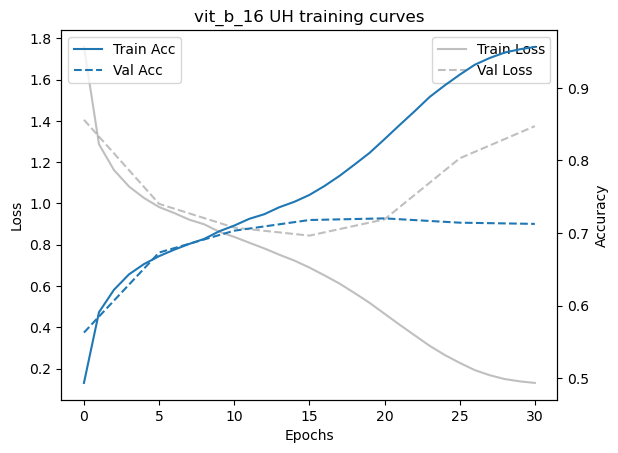

In [34]:
history = df_uh.iloc[0]['history']
history = history.replace("\'", "\"")
# load json object
history = json.loads(history)

fig, ax = plt.subplots()
NUM_EPOCHS = len(history["train_loss"])
ax.plot(range(NUM_EPOCHS), history["train_loss"], label="Train Loss", color="grey", alpha=0.5)
ax.plot(history["val_epochs"], history["val_loss"], label="Val Loss", color="grey", alpha=0.5, ls="--")
ax2 = ax.twinx()
ax2.plot(range(NUM_EPOCHS), history["train_acc"], label="Train Acc", color="tab:blue")
ax2.plot(history["val_epochs"], history["val_acc"], label="Val Acc", color="tab:blue", ls="--")
ax.legend()
ax2.legend()
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax2.set_ylabel('Accuracy')
plt.title("vit_b_16 UH training curves")
plt.show()

In [17]:
def plot_metrics_with_styled_loss(data, model_name) -> None:
    """
    Plot training and validation accuracy and loss on the same plot using twin axes,
    with styled loss lines.

    Parameters:
        data (pd.DataFrame): DataFrame containing metrics for training and validation.
        model_name (str): Name of the model for plot title.
    """
    # Ensure required keys are present
    required_keys = ['epoch', 'accuracy', 'val_accuracy', 'loss', 'val_loss']
    if not all(key in data.keys() for key in required_keys):
        raise ValueError(f"DataFrame is missing required keys: {required_keys}")
    
    epochs = data['epoch']
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plot accuracy on primary y-axis
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy', color='tab:blue')
    ax1.plot(epochs, data['accuracy'], label='Train Accuracy', color='tab:blue', linestyle='--')
    ax1.plot(epochs, data['val_accuracy'], label='Validation Accuracy', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.legend(loc='upper left')
    
    # Twin axis for loss
    ax2 = ax1.twinx()
    ax2.set_ylabel('Loss', color='tab:red')
    ax2.plot(epochs, data['loss'], label='Train Loss', color='grey', linestyle='--', alpha=0.5)
    ax2.plot(epochs, data['val_loss'], label='Validation Loss', color='grey', alpha=0.5)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.legend(loc='upper right')
    
    # Add a title and grid
    plt.title(f'Metrics for {model_name}')
    fig.tight_layout()
    plt.grid(visible=True)
    plt.show()



In [18]:
plot_metrics_with_styled_loss(history, "test")

ValueError: DataFrame is missing required keys: ['epoch', 'accuracy', 'val_accuracy', 'loss', 'val_loss']

In [9]:
# plot training curves 
def plot_training_curve(data: pd.DataFrame, title: str) -> None:
    """
    Plot training and validation accuracy and loss from a DataFrame.

    Parameters:
        data (pd.DataFrame): DataFrame containing metrics for training and validation.
        title (str): Title for the plot.
    """
    # Ensure required columns are present in the data
    required_columns = ["epoch", "train_accuracy", "val_accuracy", "train_loss", "val_loss"]
    if not all(column in data.columns for column in required_columns):
        raise ValueError(f"DataFrame is missing required columns: {required_columns}")

    # Extract metrics from the data
    epochs = data['epoch']
    train_acc = data['train_accuracy']
    val_acc = data['val_accuracy']
    train_loss = data['train_loss']
    val_loss = data['val_loss']

        # Create the figure and axes
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))

    # Plot accuracy
    axs[0].plot(epochs, train_acc, label='Train Accuracy')
    axs[0].plot(epochs, val_acc, label='Validation Accuracy')
    axs[0].set_title('Accuracy')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()
    axs[0].grid(True)

    # Plot loss
    axs[1].plot(epochs, train_loss, label='Train Loss')
    axs[1].plot(epochs, val_loss, label='Validation Loss')
    axs[1].set_title('Loss')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Loss')
    axs[1].legend()
    axs[1].grid(True)

    # Add a main title to the figure
    fig.suptitle(title, fontsize=16)

    # Adjust layout and show the plot
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [10]:
plot_training_curve(df_uh, "UH Vit_b_16 No Aug")

ValueError: DataFrame is missing required columns: ['epoch', 'train_accuracy', 'val_accuracy', 'train_loss', 'val_loss']